# FLIGHT FARE PREDICTION

img src="24flight.jpg">

## BUSINESS CASE - To predict future flight prices and plan their journey accordingly.

###### This notebook contains various ML Model which will be able to predict the future flight ticket prices

##### Pipe line of this Model Building

  * Problem Definition
  * Imorting Library
  * Loading.. File
  * Domain Analysis
  * Basic checks
  * (EDA) Exploratory Data Analysis
  * Data preprocessing
  * Feature selection
  * feature Engineering
  * Model creation for FLIGHT FARE PREDICTION
  * Model Evaluation
  * Hyperparameter tuning
  * Conclusion

# 1] PROBLEM DEFINATION
 * Prepare a complete data analysis report on the given data.
 * Create a predictive model which will help the customers to predict future flight
prices and plan their journey accordingly.

# 2] Importing library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

# 3] Loading.. File

In [2]:
data = pd.read_excel('Flight_Fare.xlsx')

In [3]:
data

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302
...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,9/04/2019,Kolkata,Banglore,CCU → BLR,19:55,22:25,2h 30m,non-stop,No info,4107
10679,Air India,27/04/2019,Kolkata,Banglore,CCU → BLR,20:45,23:20,2h 35m,non-stop,No info,4145
10680,Jet Airways,27/04/2019,Banglore,Delhi,BLR → DEL,08:20,11:20,3h,non-stop,No info,7229
10681,Vistara,01/03/2019,Banglore,New Delhi,BLR → DEL,11:30,14:10,2h 40m,non-stop,No info,12648


In [4]:
data.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              1
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        1
Additional_Info    0
Price              0
dtype: int64

In [5]:
data.loc[data.duplicated()]

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
683,Jet Airways,1/06/2019,Delhi,Cochin,DEL → NAG → BOM → COK,14:35,04:25 02 Jun,13h 50m,2 stops,No info,13376
1061,Air India,21/05/2019,Delhi,Cochin,DEL → GOI → BOM → COK,22:00,19:15 22 May,21h 15m,2 stops,No info,10231
1348,Air India,18/05/2019,Delhi,Cochin,DEL → HYD → BOM → COK,17:15,19:15 19 May,26h,2 stops,No info,12392
1418,Jet Airways,6/06/2019,Delhi,Cochin,DEL → JAI → BOM → COK,05:30,04:25 07 Jun,22h 55m,2 stops,In-flight meal not included,10368
1674,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,18:25,21:20,2h 55m,non-stop,No info,7303
...,...,...,...,...,...,...,...,...,...,...,...
10594,Jet Airways,27/06/2019,Delhi,Cochin,DEL → AMD → BOM → COK,23:05,12:35 28 Jun,13h 30m,2 stops,No info,12819
10616,Jet Airways,1/06/2019,Delhi,Cochin,DEL → JAI → BOM → COK,09:40,12:35 02 Jun,26h 55m,2 stops,No info,13014
10634,Jet Airways,6/06/2019,Delhi,Cochin,DEL → JAI → BOM → COK,09:40,12:35 07 Jun,26h 55m,2 stops,In-flight meal not included,11733
10672,Jet Airways,27/06/2019,Delhi,Cochin,DEL → AMD → BOM → COK,23:05,19:00 28 Jun,19h 55m,2 stops,In-flight meal not included,11150


# 4] Domian Analysis : Flight Fare Prediction dataset

## Flight :
* Flight or flying is the process by which an object moves through a space without contacting any planetary surface
Ther are three types of Flight commercial, general, and military aviation. shell we look on general flight.

## Airline:
* The reputation and brand image of an airline can influence its pricing strategy. Established and renowned airlines may command higher fares due to factors such as perceived quality, customer trust, and brand value like Indigo, Jet Airways, Air India, and many more.

## Date of journey:
* refers to the specific date on which a person plans to undertake a journey or travel by air. In the context of flight price prediction, the date of journey plays a crucial role in determining ticket prices.

## Source:
* This column holds the name of the place from where the passenger’s journey will start.

## Destination
* In flight price prediction involves analyzing various aspects such as the popularity and demand of the destination, geographical factors like distance, seasonality, competition among airlines operating on the route, availability of alternative transportation options, tourism and events, airport infrastructure, economic conditions, government regulations and taxes

## Route: 
* The route between the departure and arrival cities plays a significant role in determining flight fares. Different routes may have varying demand, competition among airlines, and operational costs, which can impact the pricing.

## Departure time
* The departure time of the flight Factors to consider include weekdays versus weekends, peak and off-peak travel seasons, specific times of the day (morning, afternoon, evening, or night), and the time of the year (seasonality). Additionally, the impact of holidays, events, and special occasions on flight prices should be taken into account. predictions based on the desired departure time.

## Arrival
* the time at which a public conveyance is scheduled to arrive at a given destination. The timing of the flight's arrival at the destination. Factors to consider include weekdays versus weekends, peak and off-peak travel seasons, specific times of the day (morning, afternoon, evening, or night), and the time of the year (seasonality). Additionally, the impact of holidays, events, and special occasions at the destination. predictions based on the desired arrival time.

## Duration
* Flight duration is the length of time you will spend flying. Longer flight durations tend to have higher fares due to factors such as increased fuel consumption, operational costs, and potential higher demand for non-stop flights. The duration of the flight can also be influenced by factors such as the number of stops or layovers.

## Total Stops
* The number of stops or layovers in a flight, which can impact fare prices. Flights with more stops generally have lower fares compared to non-stop flights. This is because non-stop flights offer the convenience of direct travel and often come at a premium.

## Additional Info
* Additional services such as baggage allowance, in-flight meals, Wi-Fi access, and seat selection. These services may be bundled into ticket prices or offered as add-ons, contributing to overall fare variations.

## Price
* Price of the flight for a complete journey including all the expenses before onboarding.

# 5] Basic checks

In [6]:
data.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


In [7]:
data.tail()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
10678,Air Asia,9/04/2019,Kolkata,Banglore,CCU → BLR,19:55,22:25,2h 30m,non-stop,No info,4107
10679,Air India,27/04/2019,Kolkata,Banglore,CCU → BLR,20:45,23:20,2h 35m,non-stop,No info,4145
10680,Jet Airways,27/04/2019,Banglore,Delhi,BLR → DEL,08:20,11:20,3h,non-stop,No info,7229
10681,Vistara,01/03/2019,Banglore,New Delhi,BLR → DEL,11:30,14:10,2h 40m,non-stop,No info,12648
10682,Air India,9/05/2019,Delhi,Cochin,DEL → GOI → BOM → COK,10:55,19:15,8h 20m,2 stops,No info,11753


In [8]:
data.describe()

,Price
count,10683.000000
mean,9087.064121
std,4611.359167
min,1759.000000
25%,5277.000000
50%,8372.000000
75%,12373.000000
max,79512.000000


In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10683 non-null  object
 1   Date_of_Journey  10683 non-null  object
 2   Source           10683 non-null  object
 3   Destination      10683 non-null  object
 4   Route            10682 non-null  object
 5   Dep_Time         10683 non-null  object
 6   Arrival_Time     10683 non-null  object
 7   Duration         10683 non-null  object
 8   Total_Stops      10682 non-null  object
 9   Additional_Info  10683 non-null  object
 10  Price            10683 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 918.2+ KB


In [10]:
data.shape

(10683, 11)

In [11]:
data.isnull()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...
10678,False,False,False,False,False,False,False,False,False,False,False
10679,False,False,False,False,False,False,False,False,False,False,False
10680,False,False,False,False,False,False,False,False,False,False,False
10681,False,False,False,False,False,False,False,False,False,False,False


In [12]:
categorical_features=[feature for feature in data.columns if data[feature].dtype == 'O']

In [13]:
for col in categorical_features:
    print(data[col].value_counts())
    print('----------------------------')

Jet Airways                          3849
IndiGo                               2053
Air India                            1752
Multiple carriers                    1196
SpiceJet                              818
Vistara                               479
Air Asia                              319
GoAir                                 194
Multiple carriers Premium economy      13
Jet Airways Business                    6
Vistara Premium economy                 3
Trujet                                  1
Name: Airline, dtype: int64
----------------------------
18/05/2019    504
6/06/2019     503
21/05/2019    497
9/06/2019     495
12/06/2019    493
9/05/2019     484
21/03/2019    423
15/05/2019    405
27/05/2019    382
27/06/2019    355
24/06/2019    351
1/06/2019     342
3/06/2019     333
15/06/2019    328
24/03/2019    323
6/03/2019     308
27/03/2019    299
24/05/2019    286
6/05/2019     282
1/05/2019     277
12/05/2019    259
1/04/2019     257
3/03/2019     218
9/03/2019     200
15/03/2

# 6] Exploratory Data Analysis EDA

## Univariant analysis

In [14]:
data1 = data[['Airline','Date_of_Journey','Source','Destination','Total_Stops','Additional_Info']]

In [15]:
data1

,Airline,Date_of_Journey,Source,Destination,Total_Stops,Additional_Info
0,IndiGo,24/03/2019,Banglore,New Delhi,non-stop,No info
1,Air India,1/05/2019,Kolkata,Banglore,2 stops,No info
2,Jet Airways,9/06/2019,Delhi,Cochin,2 stops,No info
3,IndiGo,12/05/2019,Kolkata,Banglore,1 stop,No info
4,IndiGo,01/03/2019,Banglore,New Delhi,1 stop,No info
...,...,...,...,...,...,...
10678,Air Asia,9/04/2019,Kolkata,Banglore,non-stop,No info
10679,Air India,27/04/2019,Kolkata,Banglore,non-stop,No info
10680,Jet Airways,27/04/2019,Banglore,Delhi,non-stop,No info
10681,Vistara,01/03/2019,Banglore,New Delhi,non-stop,No info


In [16]:
import matplotlib.pyplot as plt

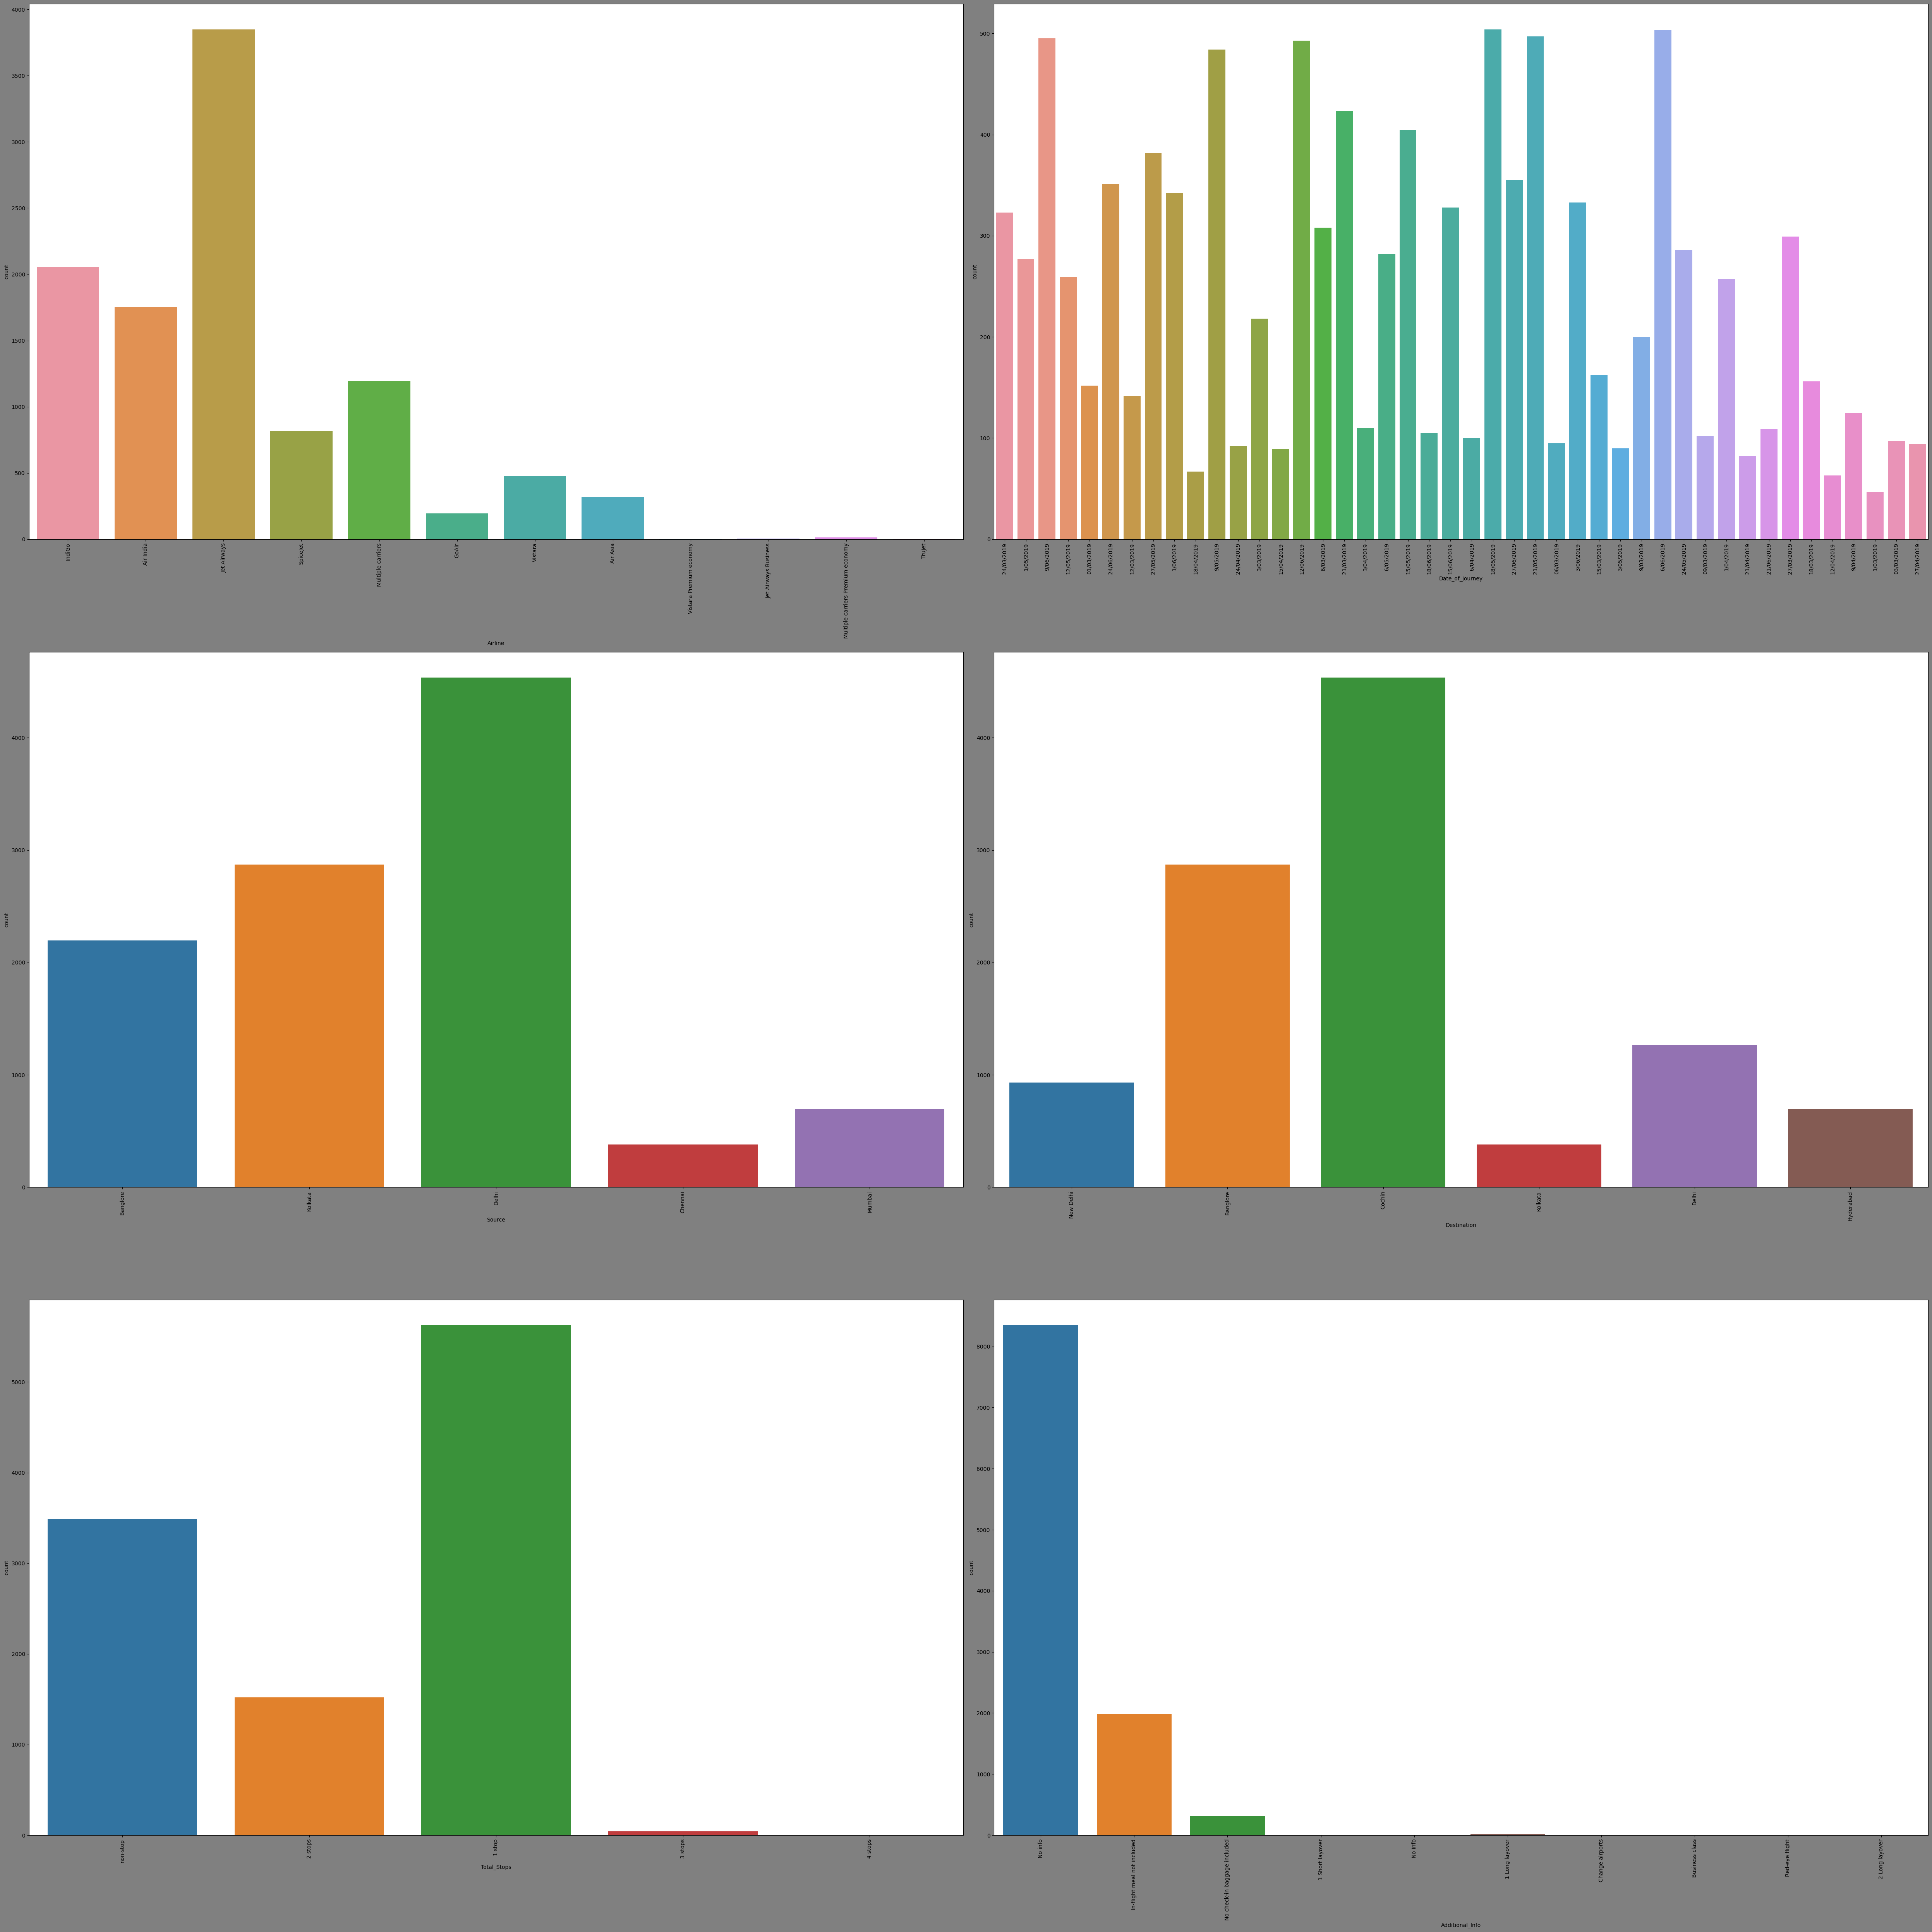

In [17]:
plt.figure(figsize=(50,50),facecolor='gray')
plotnum = 1
for i in data1:
    plt.subplot(3,2,plotnum)
    sns.countplot(x=data1[i])
    plotnum = plotnum + 1
    plt.xticks(rotation=90)
plt.tight_layout()

#### Airline
* Indigo and air India had more the 50% market capter, Jet Airways had more then 95%

#### Source
 * 96% peoples travel from Delihi ,59% of peoples travel from kolkata and 43% of peoples tavel from  banglore

#### Destination
 * 96% peoples travel to Cochin ,59% of peoples travel to banglore and 24% of peoples tavel to Delhi

#### Total_Stops
 * 53% of the Flights are nonstop flights, 97% Of Flights or 1 stop flights, 32% Of the Flights are 2 stops and 2% Of the flights are  had 3 stops

#### Additional_Info
 * 90% of the Flights did't provide a information,  In 20% of the flights meals are not include and  In 3% of the flights no check in baggage  include

## Bivariate analysis

#### Transaction count and Price (Airline Breakdown)

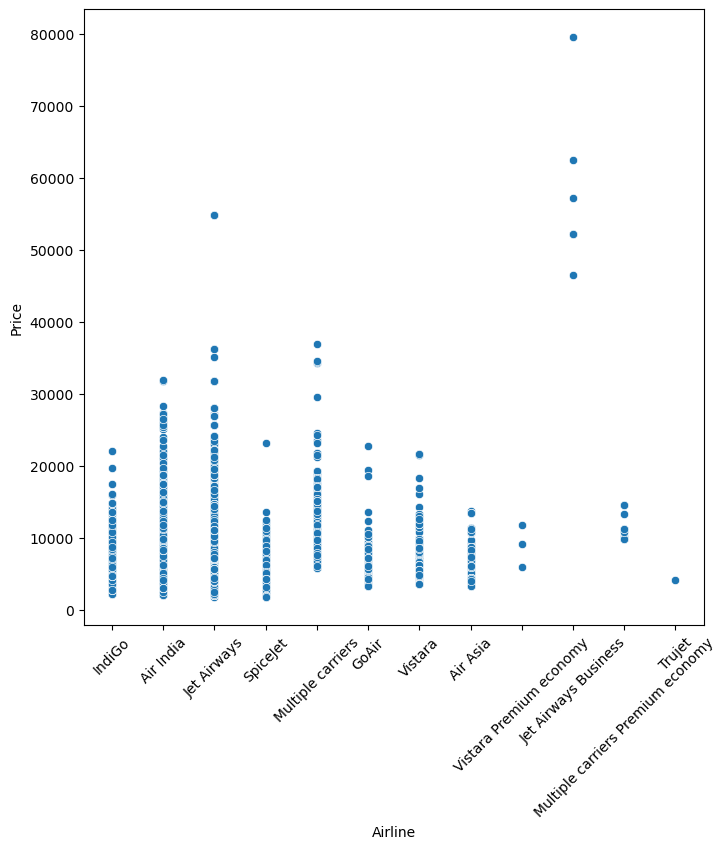

In [18]:
plt.figure(figsize=(8,8))
sns.scatterplot(x = data['Airline'], y = data['Price'])
plt.xticks(rotation=45)
plt.show()

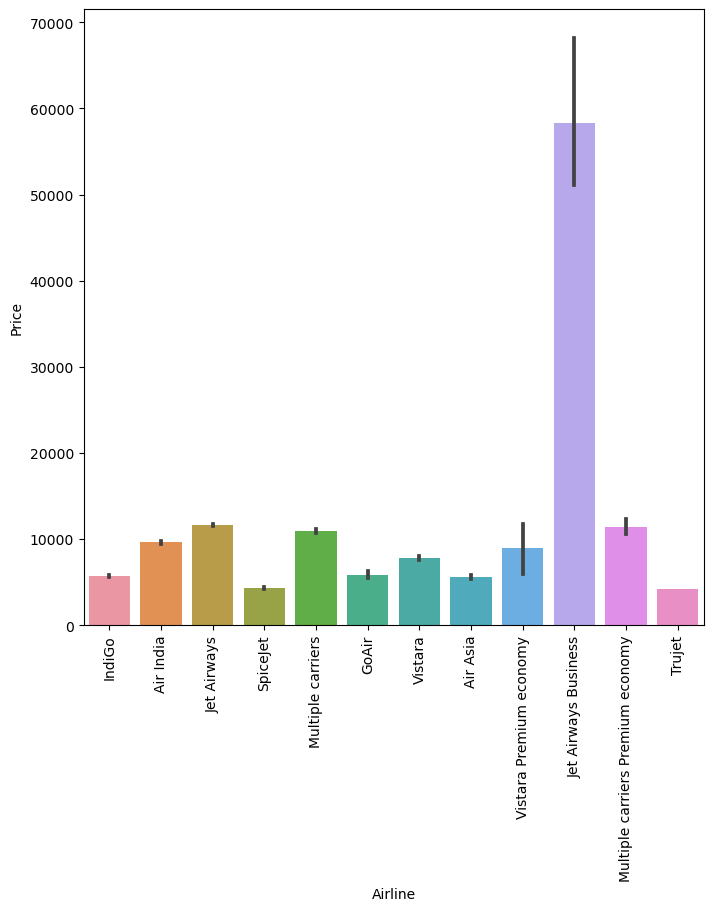

In [19]:
plt.figure(figsize=(8,8))
sns.barplot(x = data['Airline'], y = data['Price'])
plt.xticks(rotation=90)
plt.show()

# 7] Data preprocessing

In [20]:
data.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              1
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        1
Additional_Info    0
Price              0
dtype: int64

In [21]:
data.describe()

,Price
count,10683.000000
mean,9087.064121
std,4611.359167
min,1759.000000
25%,5277.000000
50%,8372.000000
75%,12373.000000
max,79512.000000


In [22]:
data.Route.mode()

0    DEL → BOM → COK
Name: Route, dtype: object

In [23]:
data.Route.value_counts()

DEL → BOM → COK          2376
BLR → DEL                1552
CCU → BOM → BLR           979
CCU → BLR                 724
BOM → HYD                 621
                         ... 
CCU → VTZ → BLR             1
CCU → IXZ → MAA → BLR       1
BOM → COK → MAA → HYD       1
BOM → CCU → HYD             1
BOM → BBI → HYD             1
Name: Route, Length: 128, dtype: int64

In [24]:
data.loc[data['Route'].isnull()==True]

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
9039,Air India,6/05/2019,Delhi,Cochin,NaN,09:45,09:25 07 May,23h 40m,NaN,No info,7480


In [25]:
data.loc[data['Route'].isnull()==True,'Route']='DEL → BOM → COK'

In [26]:
data.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              0
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        1
Additional_Info    0
Price              0
dtype: int64

In [27]:
data.loc[data['Total_Stops'].isnull()==True]

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
9039,Air India,6/05/2019,Delhi,Cochin,DEL → BOM → COK,09:45,09:25 07 May,23h 40m,NaN,No info,7480


In [28]:
data.Total_Stops.mode()

0    1 stop
Name: Total_Stops, dtype: object

In [29]:
data.loc[data['Total_Stops'].isnull()==True,'Total_Stops']= '1 stop'

In [30]:
data.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              0
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        0
Additional_Info    0
Price              0
dtype: int64

In [31]:
data.head(1)

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897


In [32]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10683 non-null  object
 1   Date_of_Journey  10683 non-null  object
 2   Source           10683 non-null  object
 3   Destination      10683 non-null  object
 4   Route            10683 non-null  object
 5   Dep_Time         10683 non-null  object
 6   Arrival_Time     10683 non-null  object
 7   Duration         10683 non-null  object
 8   Total_Stops      10683 non-null  object
 9   Additional_Info  10683 non-null  object
 10  Price            10683 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 918.2+ KB


In [33]:
data["journey_Date"]= pd.to_datetime(data['Date_of_Journey'], format= "%d/%m/%Y").dt.day
data["journey_month"]= pd.to_datetime(data['Date_of_Journey'], format= "%d/%m/%Y").dt.month
data["journey_year"]= pd.to_datetime(data['Date_of_Journey'], format= "%d/%m/%Y").dt.year
data

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,journey_Date,journey_month,journey_year
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897,24,3,2019
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662,1,5,2019
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882,9,6,2019
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218,12,5,2019
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302,1,3,2019
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,9/04/2019,Kolkata,Banglore,CCU → BLR,19:55,22:25,2h 30m,non-stop,No info,4107,9,4,2019
10679,Air India,27/04/2019,Kolkata,Banglore,CCU → BLR,20:45,23:20,2h 35m,non-stop,No info,4145,27,4,2019
10680,Jet Airways,27/04/2019,Banglore,Delhi,BLR → DEL,08:20,11:20,3h,non-stop,No info,7229,27,4,2019
10681,Vistara,01/03/2019,Banglore,New Delhi,BLR → DEL,11:30,14:10,2h 40m,non-stop,No info,12648,1,3,2019


In [34]:
data.drop(['journey_year'],axis=1,inplace=True)
data

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,journey_Date,journey_month
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897,24,3
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662,1,5
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882,9,6
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218,12,5
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302,1,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,9/04/2019,Kolkata,Banglore,CCU → BLR,19:55,22:25,2h 30m,non-stop,No info,4107,9,4
10679,Air India,27/04/2019,Kolkata,Banglore,CCU → BLR,20:45,23:20,2h 35m,non-stop,No info,4145,27,4
10680,Jet Airways,27/04/2019,Banglore,Delhi,BLR → DEL,08:20,11:20,3h,non-stop,No info,7229,27,4
10681,Vistara,01/03/2019,Banglore,New Delhi,BLR → DEL,11:30,14:10,2h 40m,non-stop,No info,12648,1,3


In [35]:
data['Dep_hour']=pd.to_datetime(data['Dep_Time']).dt.hour
data['Dep_min']=pd.to_datetime(data['Dep_Time']).dt.minute
data

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,journey_Date,journey_month,Dep_hour,Dep_min
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897,24,3,22,20
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662,1,5,5,50
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882,9,6,9,25
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218,12,5,18,5
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302,1,3,16,50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,9/04/2019,Kolkata,Banglore,CCU → BLR,19:55,22:25,2h 30m,non-stop,No info,4107,9,4,19,55
10679,Air India,27/04/2019,Kolkata,Banglore,CCU → BLR,20:45,23:20,2h 35m,non-stop,No info,4145,27,4,20,45
10680,Jet Airways,27/04/2019,Banglore,Delhi,BLR → DEL,08:20,11:20,3h,non-stop,No info,7229,27,4,8,20
10681,Vistara,01/03/2019,Banglore,New Delhi,BLR → DEL,11:30,14:10,2h 40m,non-stop,No info,12648,1,3,11,30


In [36]:
data.drop(['Dep_Time'],axis=1,inplace=True)
data

,Airline,Date_of_Journey,Source,Destination,Route,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,journey_Date,journey_month,Dep_hour,Dep_min
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,01:10 22 Mar,2h 50m,non-stop,No info,3897,24,3,22,20
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,13:15,7h 25m,2 stops,No info,7662,1,5,5,50
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,04:25 10 Jun,19h,2 stops,No info,13882,9,6,9,25
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,23:30,5h 25m,1 stop,No info,6218,12,5,18,5
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,21:35,4h 45m,1 stop,No info,13302,1,3,16,50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,9/04/2019,Kolkata,Banglore,CCU → BLR,22:25,2h 30m,non-stop,No info,4107,9,4,19,55
10679,Air India,27/04/2019,Kolkata,Banglore,CCU → BLR,23:20,2h 35m,non-stop,No info,4145,27,4,20,45
10680,Jet Airways,27/04/2019,Banglore,Delhi,BLR → DEL,11:20,3h,non-stop,No info,7229,27,4,8,20
10681,Vistara,01/03/2019,Banglore,New Delhi,BLR → DEL,14:10,2h 40m,non-stop,No info,12648,1,3,11,30


In [37]:
data['Arrival_hour']=pd.to_datetime(data['Arrival_Time']).dt.hour
data['Arrival_min']=pd.to_datetime(data['Arrival_Time']).dt.minute
data.drop(['Arrival_Time'],axis=1,inplace=True)
data

,Airline,Date_of_Journey,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,journey_Date,journey_month,Dep_hour,Dep_min,Arrival_hour,Arrival_min
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,2h 50m,non-stop,No info,3897,24,3,22,20,1,10
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,7h 25m,2 stops,No info,7662,1,5,5,50,13,15
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,19h,2 stops,No info,13882,9,6,9,25,4,25
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,5h 25m,1 stop,No info,6218,12,5,18,5,23,30
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,4h 45m,1 stop,No info,13302,1,3,16,50,21,35
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,9/04/2019,Kolkata,Banglore,CCU → BLR,2h 30m,non-stop,No info,4107,9,4,19,55,22,25
10679,Air India,27/04/2019,Kolkata,Banglore,CCU → BLR,2h 35m,non-stop,No info,4145,27,4,20,45,23,20
10680,Jet Airways,27/04/2019,Banglore,Delhi,BLR → DEL,3h,non-stop,No info,7229,27,4,8,20,11,20
10681,Vistara,01/03/2019,Banglore,New Delhi,BLR → DEL,2h 40m,non-stop,No info,12648,1,3,11,30,14,10


In [38]:
Duration = list(data['Duration'])
for i in range(len(Duration)):
    if len(Duration[i].split()) !=2:
        if "h" in Duration[i]:
            Duration[i] = Duration[i].strip()+" 0m"
        else:
            Duration[i] = "0h "+Duration[i]
Duration_hour = []
Duration_min = []
for i in range(len(Duration)):
    Duration_hour.append(int(Duration[i].split(sep = "h")[0]))
    Duration_min.append(int(Duration[i].split(sep = "m")[0].split()[-1]))
    
data["Duration_hour"] = Duration_hour
data["Duration_min"] = Duration_min 

In [39]:
data.drop(['Duration'],axis=1,inplace=True)
data

,Airline,Date_of_Journey,Source,Destination,Route,Total_Stops,Additional_Info,Price,journey_Date,journey_month,Dep_hour,Dep_min,Arrival_hour,Arrival_min,Duration_hour,Duration_min
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,non-stop,No info,3897,24,3,22,20,1,10,2,50
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,2 stops,No info,7662,1,5,5,50,13,15,7,25
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,2 stops,No info,13882,9,6,9,25,4,25,19,0
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,1 stop,No info,6218,12,5,18,5,23,30,5,25
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,1 stop,No info,13302,1,3,16,50,21,35,4,45
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,9/04/2019,Kolkata,Banglore,CCU → BLR,non-stop,No info,4107,9,4,19,55,22,25,2,30
10679,Air India,27/04/2019,Kolkata,Banglore,CCU → BLR,non-stop,No info,4145,27,4,20,45,23,20,2,35
10680,Jet Airways,27/04/2019,Banglore,Delhi,BLR → DEL,non-stop,No info,7229,27,4,8,20,11,20,3,0
10681,Vistara,01/03/2019,Banglore,New Delhi,BLR → DEL,non-stop,No info,12648,1,3,11,30,14,10,2,40


In [40]:
data.head(1)

,Airline,Date_of_Journey,Source,Destination,Route,Total_Stops,Additional_Info,Price,journey_Date,journey_month,Dep_hour,Dep_min,Arrival_hour,Arrival_min,Duration_hour,Duration_min
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,non-stop,No info,3897,24,3,22,20,1,10,2,50


In [41]:
data.drop(['Route','Additional_Info'],axis =1, inplace = True)

In [42]:
data.head(1)

,Airline,Date_of_Journey,Source,Destination,Total_Stops,Price,journey_Date,journey_month,Dep_hour,Dep_min,Arrival_hour,Arrival_min,Duration_hour,Duration_min
0,IndiGo,24/03/2019,Banglore,New Delhi,non-stop,3897,24,3,22,20,1,10,2,50


#### Encoding

In [43]:
Airline = data[["Airline"]]

Airline = pd.get_dummies(Airline,drop_first=True)

Airline.head()

,Airline_Air India,Airline_GoAir,Airline_IndiGo,Airline_Jet Airways,Airline_Jet Airways Business,Airline_Multiple carriers,Airline_Multiple carriers Premium economy,Airline_SpiceJet,Airline_Trujet,Airline_Vistara,Airline_Vistara Premium economy
0,0,0,1,0,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,0
2,0,0,0,1,0,0,0,0,0,0,0
3,0,0,1,0,0,0,0,0,0,0,0
4,0,0,1,0,0,0,0,0,0,0,0


In [44]:
Source = data[['Source']]

Source = pd.get_dummies(Source,drop_first =True)

Source.head()

,Source_Chennai,Source_Delhi,Source_Kolkata,Source_Mumbai
0,0,0,0,0
1,0,0,1,0
2,0,1,0,0
3,0,0,1,0
4,0,0,0,0


In [45]:
Destination = data[['Destination']]

Destination = pd.get_dummies(Destination,drop_first =True)

Destination.head()

,Destination_Cochin,Destination_Delhi,Destination_Hyderabad,Destination_Kolkata,Destination_New Delhi
0,0,0,0,0,1
1,0,0,0,0,0
2,1,0,0,0,0
3,0,0,0,0,0
4,0,0,0,0,1


In [46]:
data['Total_Stops'].value_counts()

1 stop      5626
non-stop    3491
2 stops     1520
3 stops       45
4 stops        1
Name: Total_Stops, dtype: int64

In [47]:
data.replace({'non-stop':0,'1 stop':1,'2 stops':2,'3 stops':3,'4 stops':4},inplace=True)

In [48]:
data.head()

,Airline,Date_of_Journey,Source,Destination,Total_Stops,Price,journey_Date,journey_month,Dep_hour,Dep_min,Arrival_hour,Arrival_min,Duration_hour,Duration_min
0,IndiGo,24/03/2019,Banglore,New Delhi,0,3897,24,3,22,20,1,10,2,50
1,Air India,1/05/2019,Kolkata,Banglore,2,7662,1,5,5,50,13,15,7,25
2,Jet Airways,9/06/2019,Delhi,Cochin,2,13882,9,6,9,25,4,25,19,0
3,IndiGo,12/05/2019,Kolkata,Banglore,1,6218,12,5,18,5,23,30,5,25
4,IndiGo,01/03/2019,Banglore,New Delhi,1,13302,1,3,16,50,21,35,4,45


In [49]:
data1 = pd.concat([data,Airline,Source,Destination],axis = 1)

In [50]:
data1

,Airline,Date_of_Journey,Source,Destination,Total_Stops,Price,journey_Date,journey_month,Dep_hour,Dep_min,...,Airline_Vistara Premium economy,Source_Chennai,Source_Delhi,Source_Kolkata,Source_Mumbai,Destination_Cochin,Destination_Delhi,Destination_Hyderabad,Destination_Kolkata,Destination_New Delhi
0,IndiGo,24/03/2019,Banglore,New Delhi,0,3897,24,3,22,20,...,0,0,0,0,0,0,0,0,0,1
1,Air India,1/05/2019,Kolkata,Banglore,2,7662,1,5,5,50,...,0,0,0,1,0,0,0,0,0,0
2,Jet Airways,9/06/2019,Delhi,Cochin,2,13882,9,6,9,25,...,0,0,1,0,0,1,0,0,0,0
3,IndiGo,12/05/2019,Kolkata,Banglore,1,6218,12,5,18,5,...,0,0,0,1,0,0,0,0,0,0
4,IndiGo,01/03/2019,Banglore,New Delhi,1,13302,1,3,16,50,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,9/04/2019,Kolkata,Banglore,0,4107,9,4,19,55,...,0,0,0,1,0,0,0,0,0,0
10679,Air India,27/04/2019,Kolkata,Banglore,0,4145,27,4,20,45,...,0,0,0,1,0,0,0,0,0,0
10680,Jet Airways,27/04/2019,Banglore,Delhi,0,7229,27,4,8,20,...,0,0,0,0,0,0,1,0,0,0
10681,Vistara,01/03/2019,Banglore,New Delhi,0,12648,1,3,11,30,...,0,0,0,0,0,0,0,0,0,1


In [51]:
data1.drop(["Airline","Source","Destination"],axis =1,inplace=True)

In [52]:
data1

,Date_of_Journey,Total_Stops,Price,journey_Date,journey_month,Dep_hour,Dep_min,Arrival_hour,Arrival_min,Duration_hour,...,Airline_Vistara Premium economy,Source_Chennai,Source_Delhi,Source_Kolkata,Source_Mumbai,Destination_Cochin,Destination_Delhi,Destination_Hyderabad,Destination_Kolkata,Destination_New Delhi
0,24/03/2019,0,3897,24,3,22,20,1,10,2,...,0,0,0,0,0,0,0,0,0,1
1,1/05/2019,2,7662,1,5,5,50,13,15,7,...,0,0,0,1,0,0,0,0,0,0
2,9/06/2019,2,13882,9,6,9,25,4,25,19,...,0,0,1,0,0,1,0,0,0,0
3,12/05/2019,1,6218,12,5,18,5,23,30,5,...,0,0,0,1,0,0,0,0,0,0
4,01/03/2019,1,13302,1,3,16,50,21,35,4,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10678,9/04/2019,0,4107,9,4,19,55,22,25,2,...,0,0,0,1,0,0,0,0,0,0
10679,27/04/2019,0,4145,27,4,20,45,23,20,2,...,0,0,0,1,0,0,0,0,0,0
10680,27/04/2019,0,7229,27,4,8,20,11,20,3,...,0,0,0,0,0,0,1,0,0,0
10681,01/03/2019,0,12648,1,3,11,30,14,10,2,...,0,0,0,0,0,0,0,0,0,1


### Removing duplicate values

In [53]:
data.loc[data.duplicated()]

,Airline,Date_of_Journey,Source,Destination,Total_Stops,Price,journey_Date,journey_month,Dep_hour,Dep_min,Arrival_hour,Arrival_min,Duration_hour,Duration_min
683,Jet Airways,1/06/2019,Delhi,Cochin,2,13376,1,6,14,35,4,25,13,50
1061,Air India,21/05/2019,Delhi,Cochin,2,10231,21,5,22,0,19,15,21,15
1348,Air India,18/05/2019,Delhi,Cochin,2,12392,18,5,17,15,19,15,26,0
1418,Jet Airways,6/06/2019,Delhi,Cochin,2,10368,6,6,5,30,4,25,22,55
1674,IndiGo,24/03/2019,Banglore,New Delhi,0,7303,24,3,18,25,21,20,2,55
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10594,Jet Airways,27/06/2019,Delhi,Cochin,2,12819,27,6,23,5,12,35,13,30
10616,Jet Airways,1/06/2019,Delhi,Cochin,2,13014,1,6,9,40,12,35,26,55
10634,Jet Airways,6/06/2019,Delhi,Cochin,2,11733,6,6,9,40,12,35,26,55
10672,Jet Airways,27/06/2019,Delhi,Cochin,2,11150,27,6,23,5,19,0,19,55


In [54]:
data.drop_duplicates(inplace = True)

In [55]:
data[data.duplicated()]

,Airline,Date_of_Journey,Source,Destination,Total_Stops,Price,journey_Date,journey_month,Dep_hour,Dep_min,Arrival_hour,Arrival_min,Duration_hour,Duration_min


# Future selection

### Droping unwanted varibles

In [56]:
data1.head(1)

,Date_of_Journey,Total_Stops,Price,journey_Date,journey_month,Dep_hour,Dep_min,Arrival_hour,Arrival_min,Duration_hour,...,Airline_Vistara Premium economy,Source_Chennai,Source_Delhi,Source_Kolkata,Source_Mumbai,Destination_Cochin,Destination_Delhi,Destination_Hyderabad,Destination_Kolkata,Destination_New Delhi
0,24/03/2019,0,3897,24,3,22,20,1,10,2,...,0,0,0,0,0,0,0,0,0,1


### Checking the co-relation

In [57]:
data1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 31 columns):
 #   Column                                     Non-Null Count  Dtype 
---  ------                                     --------------  ----- 
 0   Date_of_Journey                            10683 non-null  object
 1   Total_Stops                                10683 non-null  int64 
 2   Price                                      10683 non-null  int64 
 3   journey_Date                               10683 non-null  int64 
 4   journey_month                              10683 non-null  int64 
 5   Dep_hour                                   10683 non-null  int64 
 6   Dep_min                                    10683 non-null  int64 
 7   Arrival_hour                               10683 non-null  int64 
 8   Arrival_min                                10683 non-null  int64 
 9   Duration_hour                              10683 non-null  int64 
 10  Duration_min                      

In [58]:
X = data1.drop('Price',axis=1)
X.head()

,Date_of_Journey,Total_Stops,journey_Date,journey_month,Dep_hour,Dep_min,Arrival_hour,Arrival_min,Duration_hour,Duration_min,...,Airline_Vistara Premium economy,Source_Chennai,Source_Delhi,Source_Kolkata,Source_Mumbai,Destination_Cochin,Destination_Delhi,Destination_Hyderabad,Destination_Kolkata,Destination_New Delhi
0,24/03/2019,0,24,3,22,20,1,10,2,50,...,0,0,0,0,0,0,0,0,0,1
1,1/05/2019,2,1,5,5,50,13,15,7,25,...,0,0,0,1,0,0,0,0,0,0
2,9/06/2019,2,9,6,9,25,4,25,19,0,...,0,0,1,0,0,1,0,0,0,0
3,12/05/2019,1,12,5,18,5,23,30,5,25,...,0,0,0,1,0,0,0,0,0,0
4,01/03/2019,1,1,3,16,50,21,35,4,45,...,0,0,0,0,0,0,0,0,0,1


In [59]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 30 columns):
 #   Column                                     Non-Null Count  Dtype 
---  ------                                     --------------  ----- 
 0   Date_of_Journey                            10683 non-null  object
 1   Total_Stops                                10683 non-null  int64 
 2   journey_Date                               10683 non-null  int64 
 3   journey_month                              10683 non-null  int64 
 4   Dep_hour                                   10683 non-null  int64 
 5   Dep_min                                    10683 non-null  int64 
 6   Arrival_hour                               10683 non-null  int64 
 7   Arrival_min                                10683 non-null  int64 
 8   Duration_hour                              10683 non-null  int64 
 9   Duration_min                               10683 non-null  int64 
 10  Airline_Air India                 

In [60]:
y = data1.Price

In [61]:
y

0         3897
1         7662
2        13882
3         6218
4        13302
         ...  
10678     4107
10679     4145
10680     7229
10681    12648
10682    11753
Name: Price, Length: 10683, dtype: int64

<AxesSubplot:>

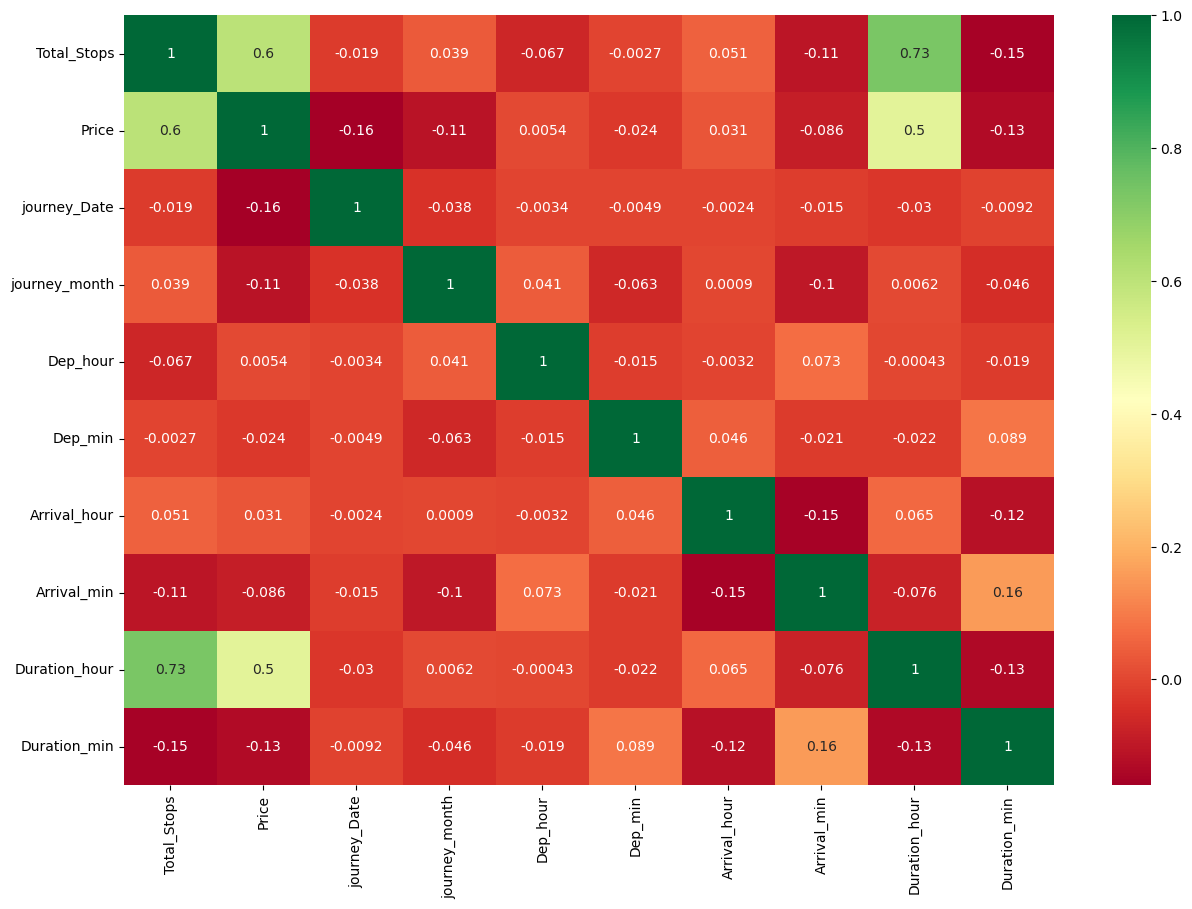

In [62]:
plt.figure(figsize=(15,10))
sns.heatmap(data.corr(),annot = True,cmap = "RdYlGn")

# Model creation

In [63]:
from sklearn.ensemble import ExtraTreesRegressor
selection = ExtraTreesRegressor()
selection.fit(X,y)

ValueError: could not convert string to float: '24/03/2019'

In [ ]:
print(selection.feature_importances_)

In [ ]:
plt.figure(figsize = (12,8))
feat_importances = pd.Series(selection.feature_importances_, index = X.columns)
feat_importances.nlargest(20).plot(kind = 'barh')
plt.show()

### Handling with out layers

In [ ]:
plt.figure(figsize = (19,19))
plotnumber = 1
for i in data:
    plt.subplot(4,3,plotnumber)
    sns.boxplot(data=data,x=i)
    plotnumber=plotnumber+1
plt.tight_layout()

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
X_train.shape,X_test.shape,y_train.shape,y_test.shape

In [ ]:
y_test

In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
x_scaled = scaler.fit_transform(x)

In [ ]:
x_scaled

In [ ]:
from sklearn.ensemble import RandomForestRegressor
reg_rf = RandomForestRegressor()
reg_rf.fit(X_train,y_train)

In [ ]:
y_pred = reg_rf.predict(X_test)

In [ ]:
reg_rf.score(X_train,y_train)

In [ ]:
reg_rf.score(X_test,y_test)

In [ ]:
sns.distplot(y_test-y_pred)
plt.show()

In [ ]:
from sklearn import metrics

In [ ]:
print('MAE:',metrics.mean_absolute_error(y_test,y_pred))
print('MSE:',metrics.mean_squared_error(y_test,y_pred))
print('RMSE:',np.sqrt(metrics.mean_squared_error(y_test,y_pred)))

In [ ]:
metrics.r2_score(y_test,y_pred)

# Hyperparameter Tuning

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

In [ ]:
#randomized search cv
    

# Number of trees in random forest
n_estimators = [int(x) for x in np.linspace(start = 100, stop = 1200, num = 12)]
#Number of features to consider ot every split
max_features = ['auto','sqrt']
#Maximum number of levels in tree
max_depth = [int(x) for x in np.linspace(5,30,num = 6)]
#Minimun of samples requried to split a node
min_samples_split = [2,5,10,15,100]
# minimun number of sample required at each leafe node
min_samples_leaf = [1,2,5,10]


In [ ]:
# create a random grid

random_grid = {'n_estimators':n_estimators,
               'max_features':max_features,
               'max_depth':max_depth,
               'min_samples_split':min_samples_split,
               'min_samples_leaf':min_samples_leaf}

In [ ]:
rf_random = RandomizedSearchCV(estimator = reg_rf, param_distributions= random_grid,scoring='neg_mean_squared_error',n_iter=10,cv = 5,verbose=2,random_state =42,n_jobs=1)

In [ ]:
rf_random.fit(X_train,y_train)

In [ ]:
rf_random.best_params_

In [ ]:
prediction = rf_random.predict(X_test)

In [ ]:
plt.figure(figsize=(8,8))
sns.distplot(bin,y_test,prediction)
show()

In [ ]:
plt.figure(figsize=(8,8))
plt.scatter(y_test,prediction,alpha = 0.5)
plt.xlabel('y_test')
plt.ylabel('y_pred')
plt.show()

In [ ]:
print('MAE:',metrics.mean_absolute_error(y_test,y_pred))
print('MSE:',metrics.mean_squared_error(y_test,y_pred))
print('RMSE:',np.sqrt(metrics.mean_squared_error(y_test,y_pred)))

# Save the model to reuse it again

In [ ]:
import pickle
# open a file where you want to store the data
file = open('flight_rf.pkl','wb')

#dump information to that file
pickle.dump(rf_random, file)

In [ ]:
model = open ('flight_rf.pkl','rb')
forest = pickle.load(model)

In [ ]:
y_prediction = forest.predict(X_test)

In [ ]:
metrics.r2_score(y_test,y_prediction)